# <div align="center"><u>kNN MDG-GS</u>

##############################################################################################################################

###  Import some useful libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import random
import time

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

### Suppress warnings

In [2]:
# import warnings

# # To suppress all warnings
# warnings.filterwarnings("ignore")

### Start time

In [3]:
# Start time
start_time = time.time()

### Load the colon-kidney MDG-GS filtered capped dataset and store it within a pandas DataFrame

In [4]:
# Load the dataset and store it withina  panda dataframe to handle it easier
df = pd.read_csv(r"C:\Users\user\Desktop\AUTH\Διπλωματική\Python\Dimensionality Reduction Methods\Graph Based Methods\MDG-GS\The colon-kidney MDG-GS filtered capped dataset.csv")

# Print the dataset
df

,1553538_s_at,1553551_s_at,1553567_s_at,1553569_at,1553570_x_at,1553588_at,1553602_at,1555653_at,1556499_s_at,1566887_x_at,...,234981_x_at,AFFX-CreX-3_at,AFFX-CreX-5_at,AFFX-hum_alu_at,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,Target,Tissue
0,101939.7,79188.2,78548.9,79695.4,81373.3,82932.5,180.9,48695.9,6341.0,7647.1875,...,12362.4000,64127.8,59227.1,90722.5,30396.7,28371.7,85830.1,57084.9,0.0,Kidney
1,62075.5,53001.9,43285.7,50123.0,51560.9,49486.0,42.6,25368.1,19004.0,1621.5000,...,5794.9000,33593.3,28815.0,54776.9,16748.8,13581.2,53322.5,37139.5,0.0,Kidney
2,168655.1,32053.3,156871.0,104305.2,133398.5,154276.8,53.6,72650.6,15652.5,3098.4000,...,13072.4000,127790.6,108451.5,214034.7,64597.8,59311.2,203060.6,146422.6,0.0,Kidney
3,127382.8,106139.6,93669.1,107430.6,108189.8,141085.6,218.4,75596.0,43916.5,6584.6000,...,12548.7000,98447.0,90216.3,112892.8,58551.7,49073.6,119460.8,95682.3,0.0,Kidney
4,202406.5,89194.2,134037.2,96200.1,111069.8,137204.3,209.6,83284.8,35598.6,7647.1875,...,15361.0375,131028.8,118324.1,191001.4,54572.5,51049.1,178178.2,129533.2,0.0,Kidney
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
541,82650.3,70763.6,67911.5,81602.7,78553.4,79633.4,129.3,29272.7,43172.3,7647.1875,...,7136.0000,46628.6,42320.0,74103.6,22165.4,20442.0,65246.8,46710.2,1.0,Colon
542,107124.6,76868.8,83311.6,65950.8,73512.4,85249.7,114.4,20338.2,70094.8,1729.4000,...,7072.8000,60248.2,46485.4,106527.6,21225.6,20067.2,80607.7,60204.9,1.0,Colon
543,80942.7,62972.8,50785.5,73531.2,74250.5,74794.9,46.8,33890.7,13787.4,1767.3000,...,3842.9000,38609.1,32498.5,67663.2,19659.4,15774.8,56065.6,43347.8,1.0,Colon
544,118584.1,103234.3,78075.0,112106.0,108282.6,105504.0,194.0,52147.5,32273.1,2877.7000,...,6153.6000,65646.3,57327.1,105755.9,34393.5,29137.7,89215.2,71290.1,1.0,Colon


### Define parameters

In [5]:
# Define parameters
number_of_splits = 50       # Number of MCCV iterations
test_size = 0.25            # 25% test data
number_of_neighbors = 3      # Number of neighbors

### Prepare data

In [6]:
# Prepare data
X = df.iloc[:, :-2].values  # Features
y = df['Target'].values     # Classes-Labels

### Function that applies Monte Carlo Cross Validation (MCCV)

In [7]:
# Function that applies Monte Carlo Cross Validation
def kNN_MCCV(X, y, n_neighbors, test_size, num_splits): # Removed default values from def for clarity with external variables
    
    train_scores = np.zeros(num_splits)
    test_scores = np.zeros(num_splits)
    train_losses = np.zeros(num_splits)
    test_losses = np.zeros(num_splits)

    test_precision_scores = np.zeros(num_splits)
    test_recall_scores = np.zeros(num_splits)
    test_f1_scores = np.zeros(num_splits)
    test_auc_roc_scores = np.zeros(num_splits)

    labels = np.unique(y)
    n_classes = len(labels)
    cm_total = np.zeros((n_classes, n_classes), dtype=np.float64)

    for i in range(num_splits):
        x_train, x_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, shuffle=True, stratify=y, random_state=i
        )

        scaler = StandardScaler()
        x_train_scaled = scaler.fit_transform(x_train)
        x_test_scaled = scaler.transform(x_test)

        model = KNeighborsClassifier(n_neighbors=n_neighbors)
        model.fit(x_train_scaled, y_train)

        y_train_pred = model.predict(x_train_scaled)
        y_test_pred = model.predict(x_test_scaled)

        # Calculate accuracy for train and test
        train_scores[i] = accuracy_score(y_train, y_train_pred)
        test_scores[i] = accuracy_score(y_test, y_test_pred)

        # Calculate and store precision, recall, f1_score and AUC-ROC metrics for the test set
        test_precision_scores[i] = precision_score(y_test, y_test_pred, average='weighted', labels=labels, zero_division=0)
        test_recall_scores[i] = recall_score(y_test, y_test_pred, average='weighted', labels=labels, zero_division=0)
        test_f1_scores[i] = f1_score(y_test, y_test_pred, average='weighted', labels=labels, zero_division=0)
        
        # If predict_proba is available
        if hasattr(model, "predict_proba"):
            y_train_proba = model.predict_proba(x_train_scaled)
            y_test_proba = model.predict_proba(x_test_scaled)

            train_losses[i] = log_loss(y_train, y_train_proba)
            test_losses[i] = log_loss(y_test, y_test_proba)
            test_auc_roc_scores[i] = roc_auc_score(y_test, y_test_proba[:, 1])
                
        else:
            train_losses[i] = np.nan
            test_losses[i] = np.nan
            test_auc_roc_scores[i] = np.nan

        cm = confusion_matrix(y_test, y_test_pred, labels=labels)
        cm_total += cm

    cm_avg = cm_total / num_splits
    
    return (
        train_scores,
        test_scores,
        train_losses,
        test_losses,
        test_precision_scores, 
        test_recall_scores,     
        test_f1_scores,         
        test_auc_roc_scores,    
        cm_avg,
        labels,
    )

### Apply MCCV

In [8]:
# Apply MCCV for kNN
train_scores, test_scores, train_losses, test_losses, \
test_precision_scores, test_recall_scores, test_f1_scores, test_auc_roc_scores, \
cm_avg, labels = kNN_MCCV(
    X, y, n_neighbors=number_of_neighbors, test_size=test_size, num_splits=number_of_splits
)

### Print results

In [9]:
print(f"Avg Training Accuracy: {np.mean(train_scores):.4f} ± {np.std(train_scores):.4f}")
print(f"Avg Evaluation Accuracy:  {np.mean(test_scores):.4f} ± {np.std(test_scores):.4f}")

Avg Training Accuracy: 0.9774 ± 0.0050
Avg Evaluation Accuracy:  0.9619 ± 0.0149


In [10]:
print(f"Avg Training Log Loss: {np.nanmean(train_losses):.4f} ± {np.nanstd(train_losses):.4f}")
print(f"Avg Evaluation Log Loss:  {np.nanmean(test_losses):.4f} ± {np.nanstd(test_losses):.4f}")

Avg Training Log Loss: 0.0495 ± 0.0061
Avg Evaluation Log Loss:  0.5964 ± 0.3815


In [11]:
print(f"Avg Evaluation Precision: {np.mean(test_precision_scores):.4f} ± {np.std(test_precision_scores):.4f}")
print(f"Avg Evaluation Recall:    {np.mean(test_recall_scores):.4f} ± {np.std(test_recall_scores):.4f}")
print(f"Avg Evaluation F1-Score:  {np.mean(test_f1_scores):.4f} ± {np.std(test_f1_scores):.4f}")
print(f"Avg Evaluation AUC-ROC:   {np.mean(test_auc_roc_scores):.4f} ± {np.std(test_auc_roc_scores):.4f}")

Avg Evaluation Precision: 0.9627 ± 0.0144
Avg Evaluation Recall:    0.9619 ± 0.0149
Avg Evaluation F1-Score:  0.9619 ± 0.0149
Avg Evaluation AUC-ROC:   0.9818 ± 0.0112


### Accuracy over MCCV iterations

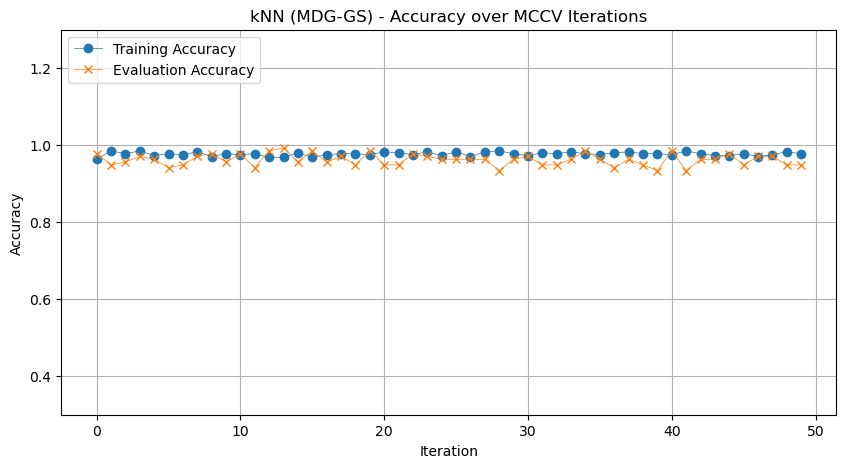

In [12]:
# Accuracy over MCCV iterations
plt.figure(figsize=(10, 5))
plt.plot(train_scores, label='Training Accuracy', marker='o', linewidth=0.5)
plt.plot(test_scores, label='Evaluation Accuracy', marker='x', linewidth=0.5)
plt.title("kNN (MDG-GS) - Accuracy over MCCV Iterations")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.legend(loc='upper left')
plt.ylim(0.3, 1.3)
plt.show()

### Log loss over MCCV iterations

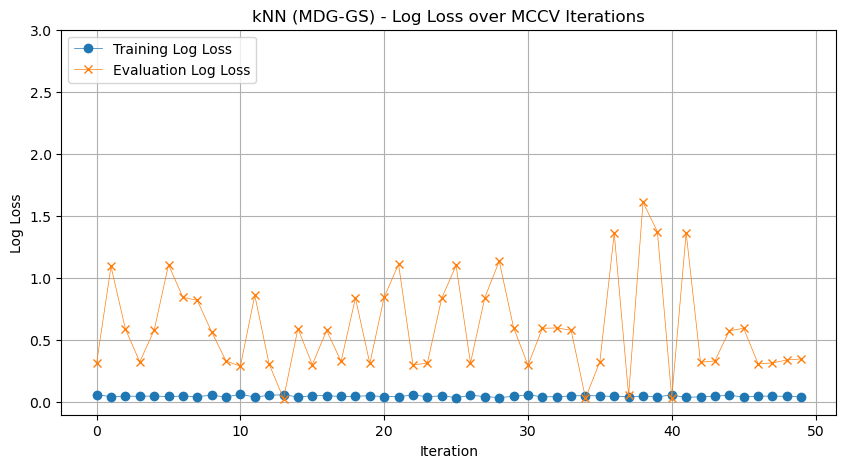

In [13]:
# Log loss over MCCV iterations
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Log Loss', marker='o', linewidth=0.5)
plt.plot(test_losses, label='Evaluation Log Loss', marker='x', linewidth=0.5)
plt.title("kNN (MDG-GS) - Log Loss over MCCV Iterations")
plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.legend()
plt.grid(True)
plt.legend(loc='upper left')
plt.ylim(-0.1, 3.0)
plt.show()

### Plot the average confussion matrix

In [14]:
# Function that plots the average confussion matrix
def plot_confusion_matrix(cm, labels, title="kNN (MDG-GS) MCCV - Average Confusion Matrix", cmap='Blues'):
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap=cmap,
                xticklabels=labels,
                yticklabels=labels)

    plt.title(title, fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.show()

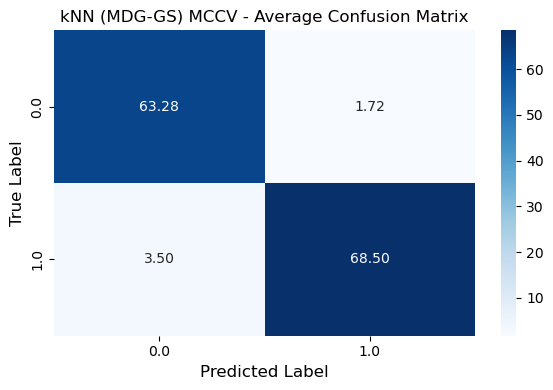

In [15]:
# Plot confusion matrix
plot_confusion_matrix(cm_avg, labels)

### End time

In [16]:
# End time
end_time = time.time()

### Elapsed time

In [17]:
# Elapsed time
elapsed_time = end_time - start_time

print(f"Elapsed time for kNN (MDG-GS): {elapsed_time:.2f} seconds")

Elapsed time for kNN (MDG-GS): 25.39 seconds
